# Notebook 7: Exploration of Probabilities and Clusters 

Notebook 7 cross-checks the Module 2 resemblance watchlist against the unsupervised K-Means clusters from Module 1, asking whether two independently derived views of Berlin's PLR agree. 

It loads the merged delivery table df_clusters_milieuschutz.csv (527 PLR with cluster_4k, oof_prob, ms_over50, on_watchlist), confirms the watchlist holds exactly 25 non-majority-designated PLR, and tabulates how those 25 distribute across the four clusters. 

A per-cluster profile then reports size, existing designation rate, watchlist share, and mean resemblance score, so the watchlist can be read against the structural groups rather than in isolation. Finally the PLR are joined to PLR_raw.geojson and drawn as a choropleth with the watchlist outlined, placing the result geographically. 

NB: This notebook adds no new modelling; it is a coherence check between the clustering and the classifier.

### Distribution of the watchlist on clusters 

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [2]:

df = pd.read_csv("../../data/final_datasets/df_clusters_milieuschutz.csv")
print(df.columns.tolist())   

#sanity checks 
watch = df[df["on_watchlist"] == True].copy()
assert len(watch) == 25, f"expected 25 on watchlist, got {len(watch)}"
assert watch["oof_prob"].isna().sum() == 0, "oof_prob missing on watchlist"
assert (watch["ms_over50"] == 0).all(), "watchlist should contain only undesignated PLR"

['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend', 're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_dichte_all', 'soc_young_to_middle_adult_share_2025', 'soc_young_to_middle_adult_share_change_2021_2025', 'soc_single_person_hh_share_change_2021_2024', 'soc_average_household_size_2024', 'soc_average_household_size_change_2021_2024', 'soc_households_without_minor_children_share_change_2021_2024', 'soc_internal_migration_volume_rate_2025', 'soc_internal_migration_volume_rate_change_2021_2025', 'soc_internal_net_migration_rate_2025', 'soc_internal_net_migration_rate_change_2021_2025', 'soc_unemployment_share_change_2020_2024', 'soc_transfer_benefit_share_2024', 'soc_transfer_benefit_share_change_2020_2024', 'soc_single_parent_household_share_2024', 'soc_single_parent_household_share_change_2021_2024', 'com_median_age_level_2026', 'com_share_solo_level_2026', 'com_share_10plus_level_2026', 'com_gastro_share_level_2026', 'com_upscale_share_level_2026', 'com_tourism_

In [3]:
#in which cluster are the PLRs on the watchlist? 
for col in ["cluster_4k"]:
    print(f"\n=== Watchlist-25 over {col} ===")
    print(watch[col].value_counts().sort_index())


=== Watchlist-25 over cluster_4k ===
cluster_4k
1     7
2     1
3    17
Name: count, dtype: int64


In [4]:
def cluster_profile(df, cluster_col):
    g = df.groupby(cluster_col)
    prof = pd.DataFrame({
        "n_plr":         g.size(),
        "n_designated":  g["ms_over50"].sum().astype(int),
        "n_watchlist":   g["on_watchlist"].sum().astype(int),
        "mean_oof_prob": g["oof_prob"].mean().round(3),
    })
    prof["designation_rate"] = (prof["n_designated"] / prof["n_plr"]).round(3)
    prof["watchlist_share"]  = (prof["n_watchlist"] / prof["n_watchlist"].sum()).round(3)
    return prof.sort_values("n_watchlist", ascending=False)

for col in ["cluster_4k"]:
    print(f"\n=== cluster profile: {col} ===")
    print(cluster_profile(df, col))


=== cluster profile: cluster_4k ===
            n_plr  n_designated  n_watchlist  mean_oof_prob  designation_rate  \
cluster_4k                                                                      
3             142            90           17          0.594             0.634   
1              90            12            7          0.250             0.133   
2             145             7            1          0.046             0.048   
0             150             0            0          0.001             0.000   

            watchlist_share  
cluster_4k                   
3                      0.68  
1                      0.28  
2                      0.04  
0                      0.00  


In [5]:
#watchlist with clusters 
ID_COL = "plr_name"   

view_cols = [ID_COL, "cluster_4k", "oof_prob", "ms_portion"]
watch_sorted = watch.sort_values("oof_prob", ascending=False)
print(watch_sorted[view_cols].to_string(index=False))

              plr_name  cluster_4k  oof_prob  ms_portion
            Uferstraße           3  0.999109    0.487524
         Koloniestraße           3  0.997601    0.221120
           Arkonaplatz           1  0.995976    0.000959
    Großgörschenstraße           3  0.992505    0.495631
           Stephankiez           3  0.986148    0.383226
           Schulstraße           3  0.985959    0.238271
     Leon-Jessel-Platz           3  0.984600    0.000000
 Humboldthain Nordwest           3  0.984006    0.129641
    Elberfelder Straße           3  0.983263    0.000026
     Lüneburger Straße           1  0.979387    0.000000
     Griechischer Park           3  0.977478    0.140887
         Brunnenstraße           2  0.976187    0.000143
          Chamissokiez           3  0.975650    0.453041
             Falkplatz           3  0.963523    0.348877
          Grazer Platz           3  0.916001    0.187098
  Oranienburger Straße           1  0.909953    0.098296
           Alt-Treptow         

### Plot of Watchlist and Clusters 

In [6]:
df  = pd.read_csv("../../data/final_datasets/df_clusters_milieuschutz.csv")
gdf = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")  

print("df :", df.columns.tolist())
print("gdf:", gdf.columns.tolist())


df : ['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend', 're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_dichte_all', 'soc_young_to_middle_adult_share_2025', 'soc_young_to_middle_adult_share_change_2021_2025', 'soc_single_person_hh_share_change_2021_2024', 'soc_average_household_size_2024', 'soc_average_household_size_change_2021_2024', 'soc_households_without_minor_children_share_change_2021_2024', 'soc_internal_migration_volume_rate_2025', 'soc_internal_migration_volume_rate_change_2021_2025', 'soc_internal_net_migration_rate_2025', 'soc_internal_net_migration_rate_change_2021_2025', 'soc_unemployment_share_change_2020_2024', 'soc_transfer_benefit_share_2024', 'soc_transfer_benefit_share_change_2020_2024', 'soc_single_parent_household_share_2024', 'soc_single_parent_household_share_change_2021_2024', 'com_median_age_level_2026', 'com_share_solo_level_2026', 'com_share_10plus_level_2026', 'com_gastro_share_level_2026', 'com_upscale_share_level_2026', 'com_tou

In [7]:
#both columns same name
#plot it 

ID = "plr_id"

df[ID]  = df[ID].astype(str)
gdf[ID] = gdf[ID].astype(str)

# gleiche Länge sicherstellen (führende Null)
print(df[ID].head().tolist())
print(gdf[ID].head().tolist())
# falls Längen differieren, die kürzere Seite auffüllen, z. B.:
# df[ID] = df[ID].str.zfill(8)

df["plr_id"] = df["plr_id"].str.zfill(8)

print(df["plr_id"].head().tolist())   # jetzt 8-stellig, ['01100101', ...]

m = gdf.merge(df, on="plr_id", how="left", suffixes=("_geo", "_df"))
print("matched:", m["oof_prob"].notna().sum(), "of", len(gdf))   # erwartet 527


['1100101', '1100102', '1100103', '1100104', '1100205']
['01100101', '01100102', '01100103', '01100104', '01100205']
['01100101', '01100102', '01100103', '01100104', '01100205']
matched: 527 of 542


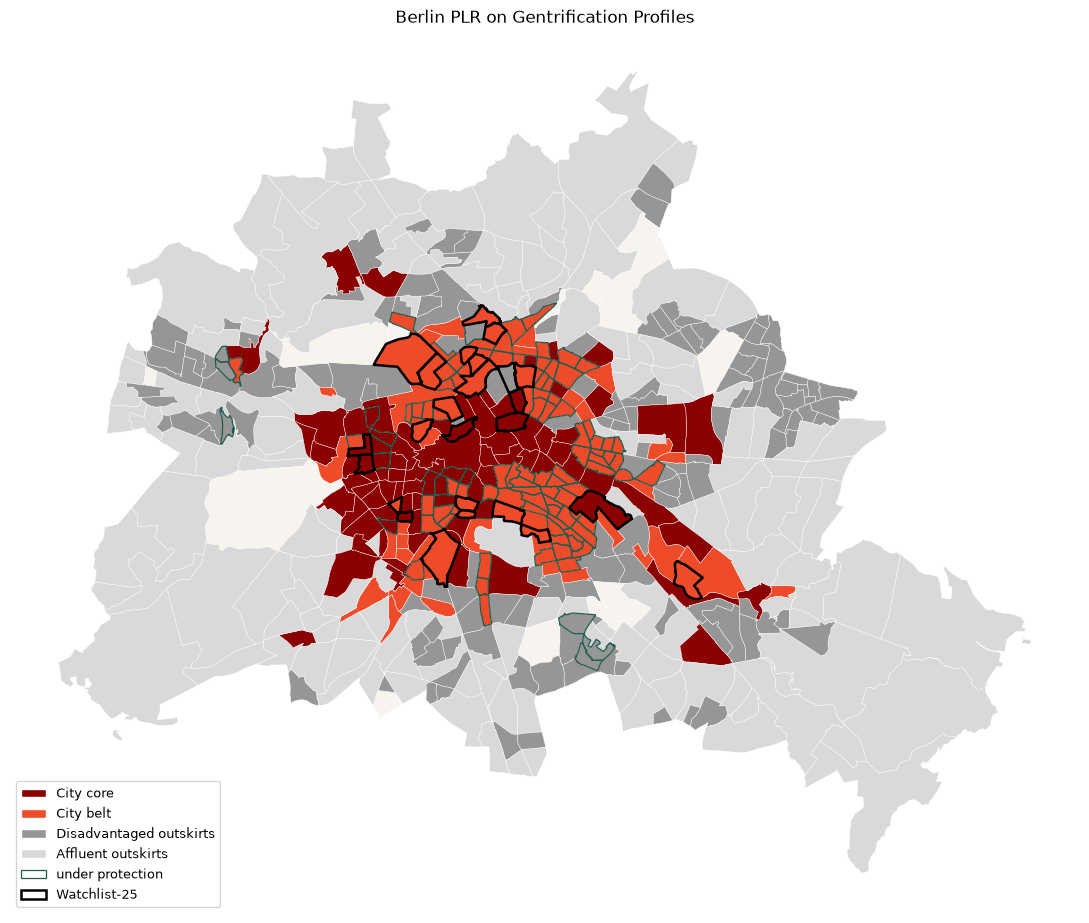

In [8]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D



cluster_labels = {1: "City core", 3: "City belt",
                  2: "Disadvantaged outskirts", 0: "Affluent outskirts"}
cluster_colors = {1: "#8B0000", 3: "#EE4B2B",
                  2: "#969696", 0: "#D9D9D9"}

CLUSTER_COL = "cluster_4k"

# Farbe je Zeile
m["_cluster_color"] = m[CLUSTER_COL].map(cluster_colors).fillna("#F7F3EE")

fig, ax = plt.subplots(figsize=(11, 11))

m.plot(color=m["_cluster_color"], ax=ax, edgecolor="white", linewidth=0.3)

# Designation: Punkt auf dem Zentroid
m[m["ms_over50"] == 1].plot(ax=ax, facecolor="none",
       edgecolor="#1D5B4E", linewidth=0.9, zorder=3)   

# Watchlist-25: fette schwarze Kontur 

m[m["on_watchlist"] == True].plot(ax=ax, facecolor="none",
       edgecolor="black", linewidth=1.8, zorder=4)

#manuelle Legende in Lese-Reihenfolge
order = [1, 3, 2, 0]

handles = [mpatches.Patch(facecolor=cluster_colors[c], edgecolor="white",
                          label=cluster_labels[c]) for c in order]
handles += [
    mpatches.Patch(facecolor="none", edgecolor="#1D5B4E", linewidth=0.9, label="under protection"),
    mpatches.Patch(facecolor="none", edgecolor="black", linewidth=1.8, label="Watchlist-25"),
]

ax.legend(handles=handles, loc="lower left", fontsize=9, frameon=True)

ax.set_title("Berlin PLR on Gentrification Profiles")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("cluster_watchlist+designated_map.png", dpi=150, bbox_inches="tight")
plt.show()

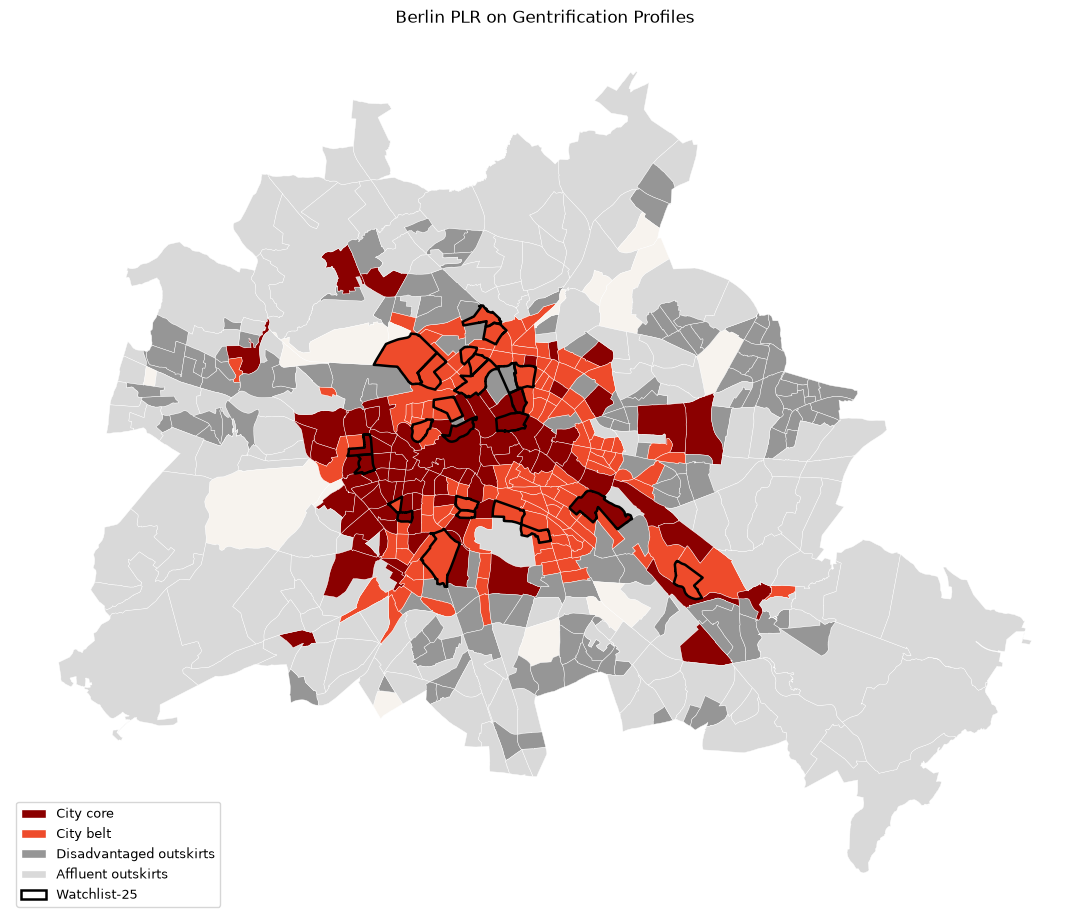

In [9]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D



cluster_labels = {1: "City core", 3: "City belt",
                  2: "Disadvantaged outskirts", 0: "Affluent outskirts"}
cluster_colors = {1: "#8B0000", 3: "#EE4B2B",
                  2: "#969696", 0: "#D9D9D9"}

CLUSTER_COL = "cluster_4k"

# Farbe je Zeile
m["_cluster_color"] = m[CLUSTER_COL].map(cluster_colors).fillna("#F7F3EE")

fig, ax = plt.subplots(figsize=(11, 11))

m.plot(color=m["_cluster_color"], ax=ax, edgecolor="white", linewidth=0.3)



# Watchlist-25: fette schwarze Kontur 

m[m["on_watchlist"] == True].plot(ax=ax, facecolor="none",
       edgecolor="black", linewidth=1.8, zorder=4)

#manuelle Legende in Lese-Reihenfolge
order = [1, 3, 2, 0]

handles = [mpatches.Patch(facecolor=cluster_colors[c], edgecolor="white",
                          label=cluster_labels[c]) for c in order]
handles += [
    mpatches.Patch(facecolor="none", edgecolor="black", linewidth=1.8, label="Watchlist-25"),
]

ax.legend(handles=handles, loc="lower left", fontsize=9, frameon=True)

ax.set_title("Berlin PLR on Gentrification Profiles")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("cluster_watchlist_withoutdesig_map.png", dpi=150, bbox_inches="tight")
plt.show()

## Result of Comparison 

The two modules converge neatly: 17 of the 25 watchlist PLR (68%) fall in cluster 3, the group that also carries the highest existing designation rate (0.634) and the highest mean resemblance score (0.594). The classifier's top candidates concentrate in exactly the cluster that best matches the designated profile. 

A further 7 (28%) sit in cluster 1 and just 1 in cluster 2, while the affluent-outskirts cluster (0) contains no watchlist PLR and shows a near-zero mean score (0.001), so the watchlist never points where the unsupervised structure sees no gentrification profile. 

The list itself spans resemblance scores from 0.999 down to 0.824 and Milieuschutz coverage (ms_portion) from 0 up to 0.496, meaning it mixes genuinely uncovered areas with PLR sitting just below the majority-designation line. This partial-coverage tail is corroboration rather than noise: several flagged PLR are already close to designation, which is what a resemblance signal to designated areas should look like. 

One caveat for reading the map: the darkest red marks the City core as a centre-to-periphery cue, not signal strength. Profile City belt actually carries the higher designation rate and watchlist share. Therefore, the map and the profile table should be read together, and read that way both point the same direction, with the supervised watchlist and the unsupervised clusters describing one spatial pattern.

Overall the map and profile show the supervised watchlist and the unsupervised clusters describing the same spatial pattern from two directions.